# Stuttering Detection: Tree-Based Ensemble Analysis
**Course**: CS204T (Artificial Intelligence)  
**Team**: 18  
**Focus**: Single Decision Trees vs. Random Forests

---

## Step 1: Initialization

In [10]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from src.extractors import WavLMExtractor
from src.data import DataManager
from src.models import DecisionTreeModel, RandomForestModel

# Dataset Configuration
AUDIO_DIR = "Stuttering Events in Podcasts Dataset/clips/stuttering-clips/clips"
CSV_PATHS = [
    "Stuttering Events in Podcasts Dataset/SEP-28k_labels.csv",
    "Stuttering Events in Podcasts Dataset/fluencybank_labels.csv"
]
FEATURE_DIR = "data/features"
fluent_dir = os.path.join(FEATURE_DIR, "fluent")
disfluent_dir = os.path.join(FEATURE_DIR, "disfluent")

## Step 2 (Optional): Operational Mode for Data Extraction
* `SKIP_EXTRACTION`: Uses features already on disk (Default).
* `FORCE_EXTRACT`: Analyzes raw audio for new files (Resumable).
* `CLEAN_START`: Wipes the database and re-extracts from zero.

In [2]:
# Operational Flags
SKIP_EXTRACTION = True
FORCE_EXTRACT = False
CLEAN_START = False
SAMPLE_LIMIT = 10000
STRICT_LABELS = True # Set to True to filter out ambiguous samples (Score 1 & 2)
NUM_CLIPS_TO_EXTRACT = 1000

if CLEAN_START:
    if os.path.exists(FEATURE_DIR):
        shutil.rmtree(FEATURE_DIR)
    print("[System] Clean start initiated. Wiped feature database.")

if not SKIP_EXTRACTION or CLEAN_START or FORCE_EXTRACT:
    extractor = WavLMExtractor("microsoft/wavlm-base")
    label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
    
    # Now using NATIVE Random Sampling logic for diversity
    extractor.extract_from_dir(
        AUDIO_DIR, 
        output_dir=FEATURE_DIR, 
        label_dict=label_dict, 
        limit=NUM_CLIPS_TO_EXTRACT, 
        random_sample=True
    )
else:
    print("[System] Skipping extraction. Using existing data on disk.")

[System] Skipping extraction. Using existing data on disk.


## Step 3: Data Preparation

In [3]:
label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
manager = DataManager(None, None)

# Loading .npy features into matrices
X, y = manager.load_from_folders(fluent_dir, disfluent_dir, limit=SAMPLE_LIMIT, label_dict=label_dict)
X_train, X_val, X_test, y_train, y_val, y_test = manager.get_splits(test_size=0.15, val_size=0.15)

# Handle Class Imbalance
X_train_bal, y_train_bal = manager.balance_data(X_train, y_train, strategy="oversample")

# Setting these to variables for training clarity
X_train_final = manager.preprocess(X_train_bal, method="standard")
X_test_final = manager.preprocess(X_test, method="standard")

[DataManager] Quality Filter: Removed 3938 low-quality samples.
[DataManager] Smart Load: Pre-selected 5000 fluent and 5000 disfluent files.


## Step 4: Model 1 - Decision Tree

In [4]:
dt_model = DecisionTreeModel("Decision_Tree_Baseline", max_depth=10)
dt_model.train(X_train_final, y_train_bal)

print("
--- Evaluation on Unseen Test Set ---")
dt_model.evaluate(X_test_final, y_test)

[Model: Decision_Tree_Baseline] Initialized.
[Decision_Tree_Baseline] Building Logic Tree (Max Depth: 10)...

--- Evaluation on Unseen Test Set ---

--- Evaluation: Decision_Tree_Baseline ---
Accuracy: 0.5940
Precision: 0.6080
Recall: 0.5293
F1: 0.5659

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      494             256            
True: Stutter(1)     353             397            


{'accuracy': 0.594,
 'precision': 0.6079632465543645,
 'recall': 0.5293333333333333,
 'f1': 0.5659301496792587,
 'confusion_matrix': array([[494, 256],
        [353, 397]])}

## Step 5: Model 2 - Random Forest (Ensemble)

In [5]:
rf_model = RandomForestModel("Random_Forest_Ensemble", n_estimators=100, max_depth=15)
rf_model.train(X_train_final, y_train_bal)

print("
--- Evaluation on Unseen Test Set ---")
rf_model.evaluate(X_test_final, y_test)

[Model: Random_Forest_Ensemble] Initialized.
[Random_Forest_Ensemble] Planting 100 Trees (Max Depth: 15)...

--- Evaluation on Unseen Test Set ---

--- Evaluation: Random_Forest_Ensemble ---
Accuracy: 0.6433
Precision: 0.7363
Recall: 0.4467
F1: 0.5560

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      630             120            
True: Stutter(1)     415             335            


{'accuracy': 0.6433333333333333,
 'precision': 0.7362637362637363,
 'recall': 0.44666666666666666,
 'f1': 0.5560165975103735,
 'confusion_matrix': array([[630, 120],
        [415, 335]])}

# Part 2: Hyperparameter Optimization
---

In [6]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Prepare Cross-Validation Split (Combining Train + Val)
X_train_val = np.vstack((X_train_final, manager.preprocess(X_val, method="standard", fit=False)))
y_train_val = np.hstack((y_train_bal, y_val))

# -1 for training indices, 0 for validation indices
split_indices = np.hstack((
    -1 * np.ones(len(X_train_final)),
    idx_val := np.zeros(len(X_val))
))
ps = PredefinedSplit(test_fold=split_indices)

print(f"Tuning setup ready. Total samples: {len(X_train_val)}")

Tuning setup ready. Total samples: 8500


In [7]:
print("--- Tuning Decision Tree ---")
dt_params = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=ps, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train_val, y_train_val)

print(f"Best DT Params: {dt_grid.best_params_}")
print(f"Best DT Val Accuracy: {dt_grid.best_score_:.4f}")

--- Tuning Decision Tree ---
Best DT Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
Best DT Val Accuracy: 0.6033


In [8]:
print("--- Tuning Random Forest ---")
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20, None],
    'max_features': ['sqrt', 'log2', None]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=ps, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_val, y_train_val)

print(f"Best RF Params: {rf_grid.best_params_}")
print(f"Best RF Val Accuracy: {rf_grid.best_score_:.4f}")

--- Tuning Random Forest ---
Best RF Params: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}
Best RF Val Accuracy: 0.6807



--- Final Optimized Random Forest Evaluation ---
              precision    recall  f1-score   support

         0.0       0.63      0.78      0.70       750
         1.0       0.71      0.54      0.62       750

    accuracy                           0.66      1500
   macro avg       0.67      0.66      0.66      1500
weighted avg       0.67      0.66      0.66      1500



NameError: name 'accuracy_score' is not defined

<Figure size 600x500 with 0 Axes>

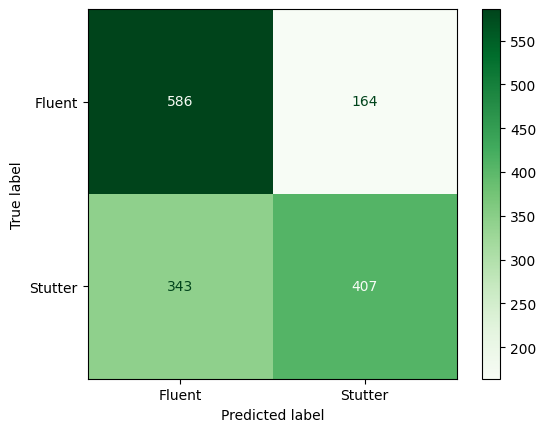

In [11]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

best_rf = rf_grid.best_estimator_
y_pred = best_rf.predict(X_test_final)

print("
--- Final Optimized Random Forest Evaluation ---")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(best_rf, X_test_final, y_test, cmap='Greens', display_labels=['Fluent', 'Stutter'])
plt.title(f"Optimized Random Forest (Acc: {accuracy_score(y_test, y_pred):.4f})")
plt.show()